# Observation resampling: the block-method family

Observation-resampling methods rebuild a replicate from the original rows of your series. Because every value in a replicate is a value you actually observed, these methods preserve the empirical marginal distribution exactly, and they record which observations were left out, so they are out-of-bag capable. Model-based methods (residual, sieve) instead simulate new values from a fitted model, so they have no observation-index provenance.

`tsbootstrap` ships six observation-resampling methods. We line all six up with a one-line steer for each, surface the edge effect that separates the moving block from the circular block, and finish on the automatic Politis-White block length. The decision-guide tutorial covers when to reach for a model-based method instead.

In [1]:
# On Colab or Binder, install tsbootstrap first (skipped if already present):
try:
    import tsbootstrap  # noqa: F401
except ImportError:
    %pip install -q "tsbootstrap[examples]"

## Two test series

A synthetic AR(1) with known structure, `x[t] = phi * x[t-1] + e[t]` with `phi = 0.6`, and the real `load_lynx` series from sktime, a strongly cyclical count of lynx trappings. Both are kept short so the notebook runs quickly on CI. The block methods do not care which one you feed them; the contrast just shows the methods on synthetic and real data.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sktime.datasets import load_lynx

from tsbootstrap import (
    IID,
    CircularBlock,
    MovingBlock,
    NonOverlappingBlock,
    StationaryBlock,
    TaperedBlock,
    bootstrap,
)
from tsbootstrap.block.pwsd import optimal_block_length

rng = np.random.default_rng(0)
n, phi = 240, 0.6
x = np.zeros(n)
e = rng.standard_normal(n)
for t in range(1, n):
    x[t] = phi * x[t - 1] + e[t]

lynx = load_lynx().to_numpy(dtype=float)  # 114 yearly lynx trapping counts

B = 300  # replicates per call; small for CI
print(f"AR(1): n = {x.shape[0]},  lynx: n = {lynx.shape[0]}")

AR(1): n = 240,  lynx: n = 114


A quick look at both series. The lynx counts show the famous roughly ten-year boom-bust cycle, the kind of local structure a block method aims to preserve.

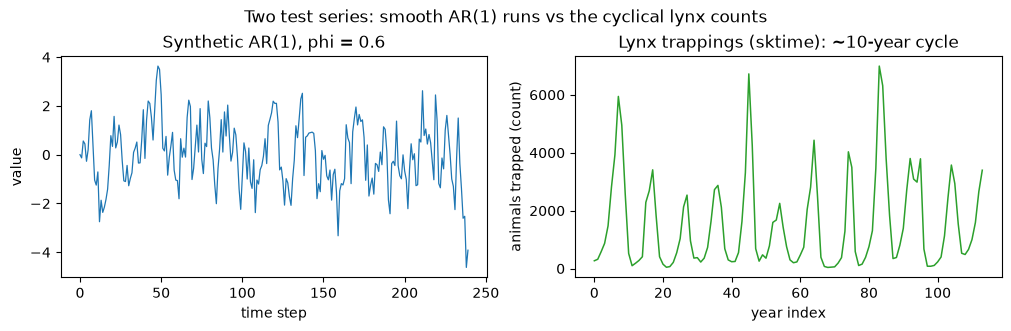

In [3]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 3.2), constrained_layout=True)
ax0.plot(x, color="tab:blue", lw=0.9)
ax0.set_title("Synthetic AR(1), phi = 0.6")
ax0.set_xlabel("time step")
ax0.set_ylabel("value")
ax1.plot(lynx, color="tab:green", lw=1.1)
ax1.set_title("Lynx trappings (sktime): ~10-year cycle")
ax1.set_xlabel("year index")
ax1.set_ylabel("animals trapped (count)")
fig.suptitle("Two test series: smooth AR(1) runs vs the cyclical lynx counts")
plt.show()

## A helper to plot replicates

Every method below is one `bootstrap(...)` call returning a result whose `.values()` is a `(n_bootstraps, n)` array. This helper overlays a few replicates on the original so the methods are visually comparable.

In [4]:
from matplotlib.lines import Line2D


def show_replicates(series, spec, title, color="tab:blue", k=6, seed=1):
    """Run one bootstrap and plot k replicates over the original series."""
    res = bootstrap(series, method=spec, n_bootstraps=B, random_state=seed)
    samples = res.values()
    fig, ax = plt.subplots(figsize=(8, 2.9), constrained_layout=True)
    for i in range(k):
        ax.plot(samples[i], color=color, alpha=0.35, lw=0.8)
    ax.plot(series, color="black", lw=1.6, label="original")
    ax.set_title(title)
    ax.set_xlabel("time step")
    ax.set_ylabel("value")
    # One proxy handle for the faint replicate cloud, plus the solid original.
    handles = [
        Line2D([0], [0], color="black", lw=1.6, label="original"),
        Line2D([0], [0], color=color, lw=1.2, alpha=0.6, label=f"{k} replicates"),
    ]
    ax.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.9)
    plt.show()
    return res

## 1. IID

**When to use:** only when you have already decided the observations are independent. **When not:** any serial dependence, because IID shuffles rows independently and destroys all ordering, collapsing the autocorrelation to zero. It is the baseline that every block method improves on.

`IID()` takes no block-length parameter.

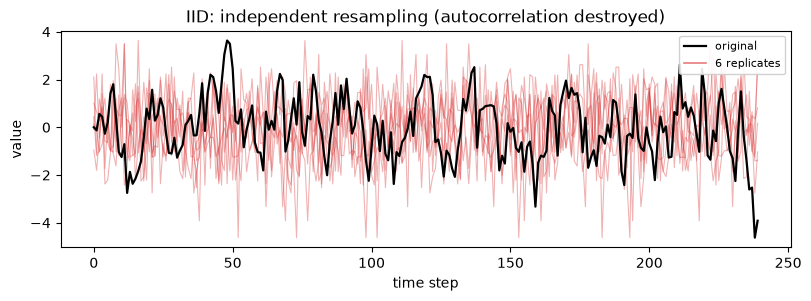

In [5]:
_ = show_replicates(
    x,
    IID(),
    "IID: independent resampling (autocorrelation destroyed)",
    color="tab:red",
)

The replicates look like white noise: the smooth runs of the original AR(1) are gone because neighbouring points are no longer drawn together.

## 2. MovingBlock

**When to use:** the default stationary block bootstrap; overlapping fixed-length blocks preserve local dependence and every interior block start is equally likely. **When not:** when the two ends of the series matter and you cannot tolerate them being under-sampled (see the edge-effect section), or when a non-integer mean block length suits you better (use StationaryBlock).

`MovingBlock` takes `block_length` (an int or `"auto"`).

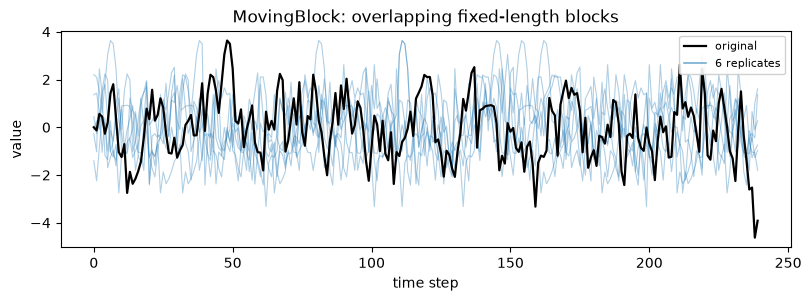

In [6]:
_ = show_replicates(
    x,
    MovingBlock(block_length="auto"),
    "MovingBlock: overlapping fixed-length blocks",
)

## 3. CircularBlock

**When to use:** when you want every observation, including the first and last, sampled with equal probability; the blocks wrap around the end of the series back to the start, so coverage is flat. **When not:** when wrapping the series end onto its beginning is not meaningful, for example a series with a strong trend where the last value and the first value are far apart.

`CircularBlock` takes `block_length`.

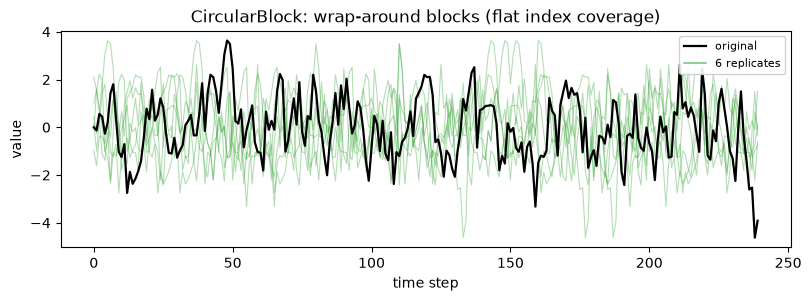

In [7]:
_ = show_replicates(
    x,
    CircularBlock(block_length="auto"),
    "CircularBlock: wrap-around blocks (flat index coverage)",
    color="tab:green",
)

## 4. StationaryBlock

**When to use:** when you want the replicate itself to be stationary; block lengths are random (geometric) with a chosen average, which removes the artefacts a single fixed length can impose. **When not:** when you need a guaranteed exact block length, since here the length is random around its mean.

Note the parameter name: StationaryBlock uses `avg_block_length`, not `block_length`, because the length is a mean, not a fixed value.

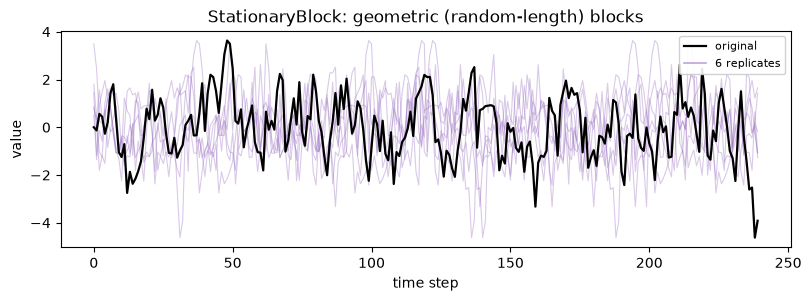

In [8]:
_ = show_replicates(
    x,
    StationaryBlock(avg_block_length="auto"),
    "StationaryBlock: geometric (random-length) blocks",
    color="tab:purple",
)

## 5. NonOverlappingBlock

**When to use:** when you want disjoint blocks, so each observation belongs to exactly one block partition and the blocks are independent by construction; simple and classic (Carlstein 1986). **When not:** when you need the smoother coverage of overlapping blocks, since with disjoint blocks there are fewer distinct blocks to draw from, which raises variance.

`NonOverlappingBlock` takes `block_length`.

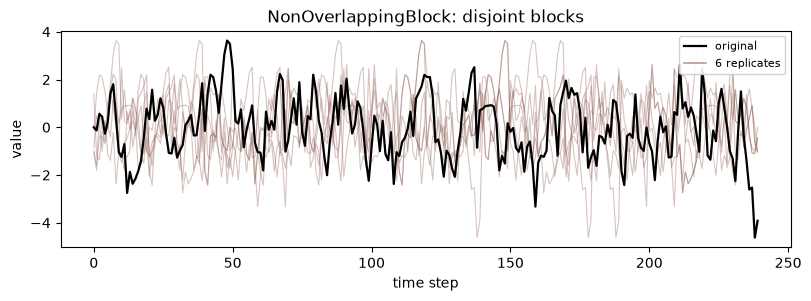

In [9]:
_ = show_replicates(
    x,
    NonOverlappingBlock(block_length="auto"),
    "NonOverlappingBlock: disjoint blocks",
    color="tab:brown",
)

## 6. TaperedBlock

**When to use:** when the seam bias of plain block methods bothers you; a window down-weights the edges of each block so the joins contribute less, which recenters dependence-sensitive estimators (such as an AR coefficient) closer to the truth. **When not:** when you need replicates that preserve the raw marginal scale exactly, since the taper reweights values near block edges.

`TaperedBlock` takes `block_length` plus a `window`. The available windows are `bartlett`, `blackman`, `hamming`, `hann`, and `tukey`. We show two of them.

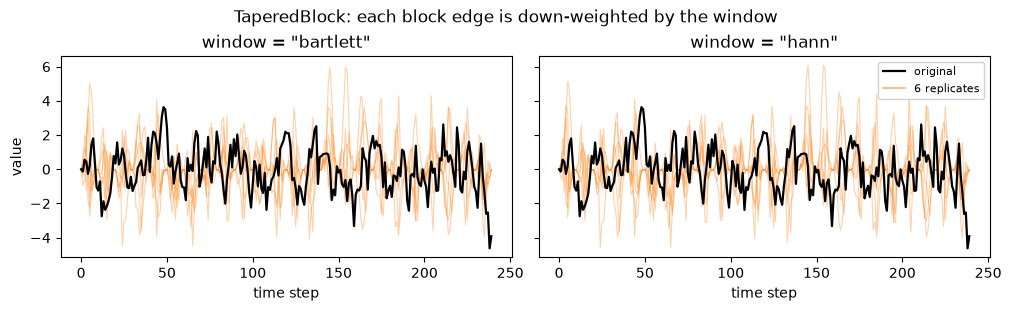

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.0), sharey=True, constrained_layout=True)
for ax, win in zip(axes, ["bartlett", "hann"]):
    res = bootstrap(
        x,
        method=TaperedBlock(block_length="auto", window=win),
        n_bootstraps=B,
        random_state=1,
    )
    samples = res.values()
    for i in range(6):
        ax.plot(samples[i], color="tab:orange", alpha=0.35, lw=0.8)
    ax.plot(x, color="black", lw=1.6, label="original")
    ax.set_title(f'window = "{win}"')
    ax.set_xlabel("time step")
axes[0].set_ylabel("value")
handles = [
    Line2D([0], [0], color="black", lw=1.6, label="original"),
    Line2D([0], [0], color="tab:orange", lw=1.2, alpha=0.6, label="6 replicates"),
]
axes[1].legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.9)
fig.suptitle("TaperedBlock: each block edge is down-weighted by the window")
plt.show()

## Edge effects: MovingBlock starves the ends, CircularBlock is flat

This is the practical difference between the moving and circular blocks. A moving block of length `L` must start in `[0, n - L]`, so the first and last observations can only fall inside a handful of blocks and are therefore under-sampled. The circular block wraps around, so every index appears with equal probability. `result.inbag_counts()` records how many times each original index was used in each replicate; averaging over replicates exposes the pattern directly.

We fix an explicit block length so the comparison is exact.

In [11]:
import pandas as pd

L = 25
mb = bootstrap(x, method=MovingBlock(block_length=L), n_bootstraps=B, random_state=3)
cb = bootstrap(x, method=CircularBlock(block_length=L), n_bootstraps=B, random_state=3)

mb_usage = mb.inbag_counts().mean(axis=0)
cb_usage = cb.inbag_counts().mean(axis=0)

# Summarise the ends versus the middle.
edge = list(range(L)) + list(range(n - L, n))
mid = list(range(n // 2 - L, n // 2 + L))
usage_summary = pd.DataFrame(
    {
        "edge mean usage": [mb_usage[edge].mean(), cb_usage[edge].mean()],
        "middle mean usage": [mb_usage[mid].mean(), cb_usage[mid].mean()],
    },
    index=["MovingBlock", "CircularBlock"],
).round(3)
usage_summary

,edge mean usage,middle mean usage
MovingBlock,0.598,1.107
CircularBlock,1.048,0.988


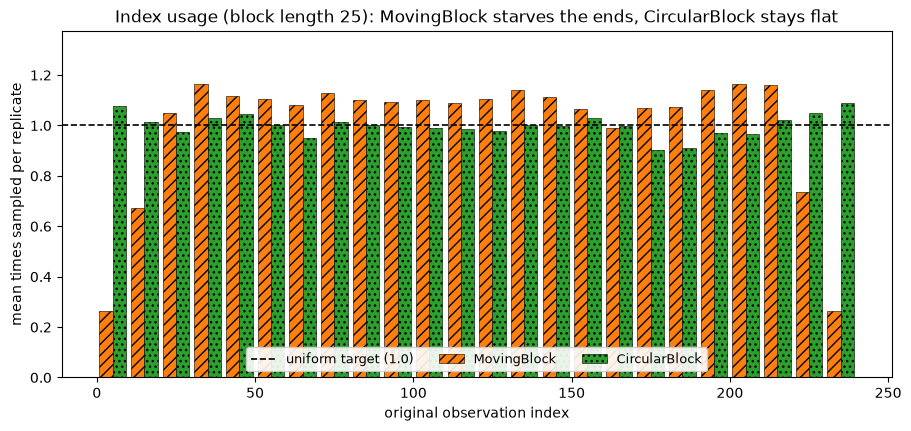

In [12]:
# Bar chart of mean usage by index position, binned for readability.
n_bins = 24
edges = np.linspace(0, n, n_bins + 1).astype(int)
centers = (edges[:-1] + edges[1:]) / 2
width = (n / n_bins) * 0.42
mb_binned = np.array([mb_usage[a:b].mean() for a, b in zip(edges[:-1], edges[1:])])
cb_binned = np.array([cb_usage[a:b].mean() for a, b in zip(edges[:-1], edges[1:])])

fig, ax = plt.subplots(figsize=(9, 4.2), constrained_layout=True)
# Distinguish the two series by hatch as well as color (colorblind-safe).
ax.bar(
    centers - width / 2,
    mb_binned,
    width=width,
    color="tab:orange",
    hatch="///",
    edgecolor="black",
    linewidth=0.4,
    label="MovingBlock",
)
ax.bar(
    centers + width / 2,
    cb_binned,
    width=width,
    color="tab:green",
    hatch="...",
    edgecolor="black",
    linewidth=0.4,
    label="CircularBlock",
)
ax.axhline(1.0, color="black", ls="--", lw=1.2, label="uniform target (1.0)")
ax.set_xlabel("original observation index")
ax.set_ylabel("mean times sampled per replicate")
ax.set_title(
    f"Index usage (block length {L}): MovingBlock starves the ends, CircularBlock stays flat"
)
ax.set_ylim(0, max(mb_binned.max(), cb_binned.max()) * 1.18)
ax.legend(loc="lower center", ncol=3, fontsize=9, framealpha=0.9)
plt.show()

The orange bars droop at both ends: the first and last observations of the moving block are visibly under-represented, while the green circular block sits on the uniform line across the whole series. If the boundary points of your series carry real information, prefer the circular block, accepting that it joins the end of the series back to its start.

## Automatic block length: the Politis-White rule

Passing `block_length="auto"` (or `avg_block_length="auto"`) calls the Politis-White spectral-density plug-in selector under the hood. You can call it directly with `optimal_block_length`. It expects a 2D `(n, d)` array, so we reshape a univariate series with `x.reshape(-1, 1)`. The `kind` argument defaults to `"circular"` (the moving/circular constant); pass `"stationary"` for the stationary-bootstrap constant.

In [13]:
auto_circular = optimal_block_length(x.reshape(-1, 1))  # kind defaults to 'circular'
auto_stationary = optimal_block_length(x.reshape(-1, 1), kind="stationary")
auto_lynx = optimal_block_length(lynx.reshape(-1, 1))

pd.DataFrame(
    {
        "series": ["AR(1)", "AR(1)", "lynx"],
        "kind": ["circular", "stationary", "circular"],
        "auto block length": [auto_circular, auto_stationary, auto_lynx],
    }
)

,series,kind,auto block length
0,AR(1),circular,10
1,AR(1),stationary,9
2,lynx,circular,4


These are the lengths `"auto"` would have chosen. One caveat: the Politis-White length is optimal for the variance-of-the-mean target. It is not guaranteed optimal for every statistic you might bootstrap, so treat it as a sensible default and override it when your estimator calls for something else.

### Picking among the six

All six methods here resample the rows you observed, so they keep the empirical marginal and expose out-of-bag structure. They differ in how they stitch blocks together: IID not at all, the moving and non-overlapping blocks with hard seams, the circular block with wrap-around, the stationary block with random lengths, and the tapered block with down-weighted edges. Pick by what your series and estimator can tolerate, and let `"auto"` set the length unless you have a reason to override it.